In [ ]:
# Setup path and load utils
import sys, os
sys.path.append(os.path.abspath("../src"))
import numpy as np
print("Current working directory:", os.getcwd())
import sys
for p in sys.path:
    print(p)


In [ ]:
from feature import IQFeatureExtractor
from utils import list_npys_by_timestamp, load_iq_burst
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature extraction
extractor = IQFeatureExtractor()
records = []

for filename, timestamp in list_npys_by_timestamp("../data/raw"):
    samples = load_iq_burst(f"../data/raw/{filename}")
    features = extractor.compute_features(samples)
    features['timestamp'] = timestamp.isoformat()
    records.append(features)

df_features = pd.DataFrame(records)
df_features.to_csv("../data/features.csv", index=False)
print(df_features.columns.tolist())  # <- Confirm all fields

#['iq_offset_real', 'iq_offset_imag', 'iq_gain_imbalance_db', 'iq_phase_imbalance_rad', 'rms_power', 'spectral_entropy', 'cfo_estimate_rad', 'time_entropy', 'rise_index', 'i_skew', 'q_skew', 'i_kurtosis', 'q_kurtosis', 'fft_peak_0', ..., 'timestamp']


/tmp/ipykernel_17386/770409362.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/isesdr/Downloads/ble-RFFingerprinting/ble-rff-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


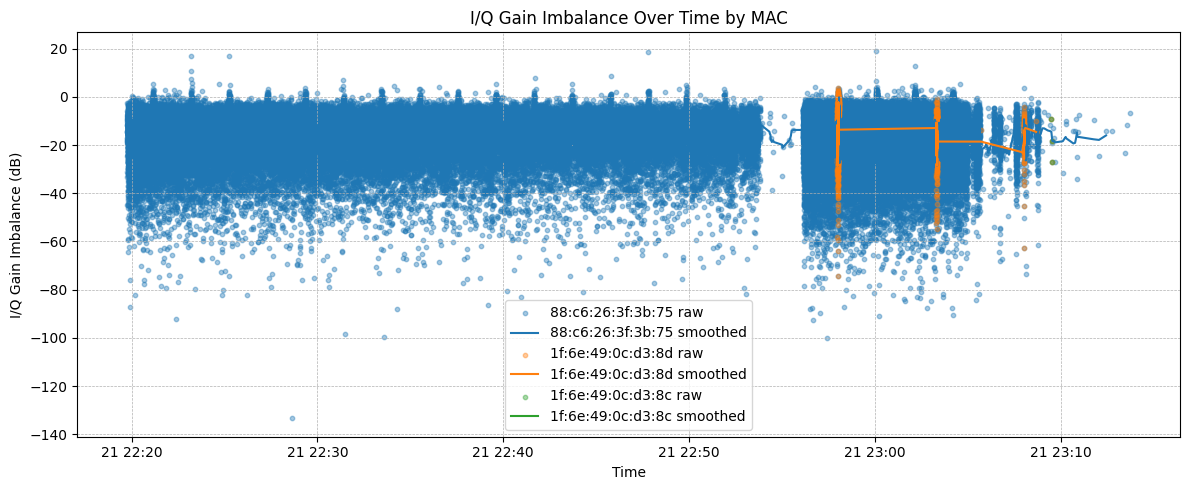

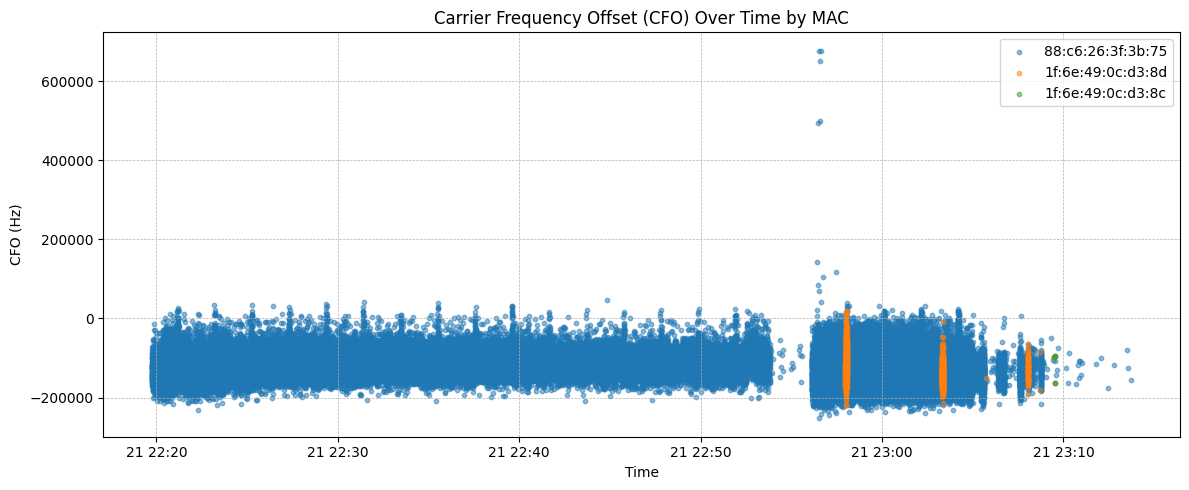

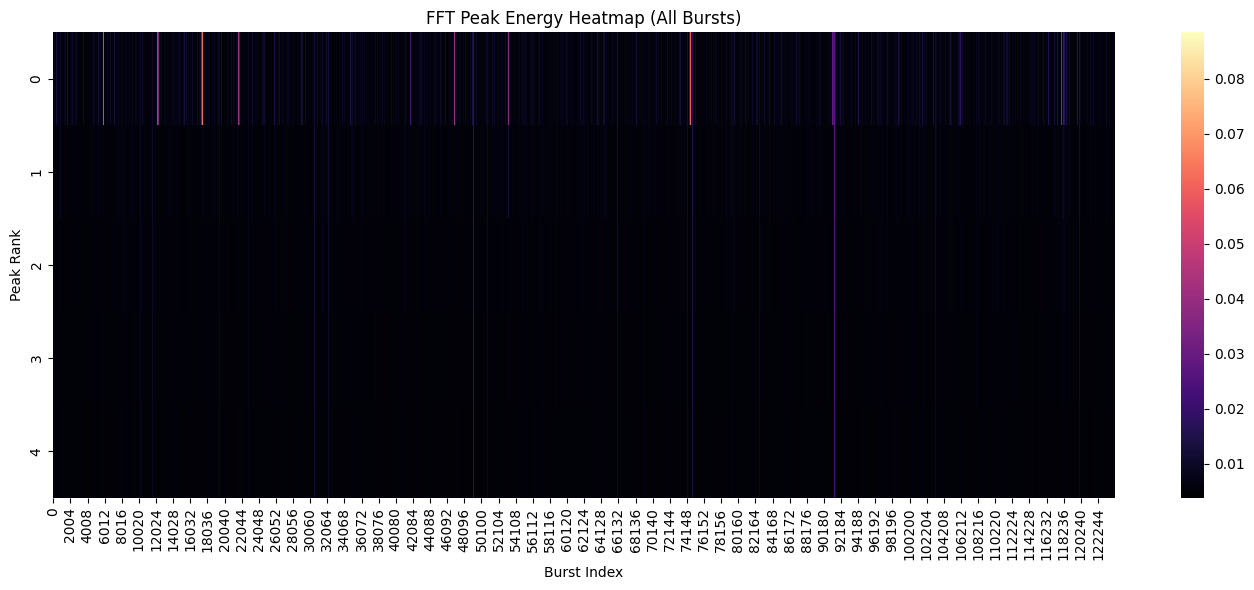

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot Gain Imbalance
plt.figure(figsize=(12, 5))
for mac in top_macs:  # Assume you already have 'top_macs'
    subset = df_exploded[df_exploded['matched_macs'] == mac]
    subset = subset.sort_values('timestamp')
    subset['iq_gain_imbalance_db'] = 20 * np.log10(np.abs(subset['iq_gain_imbalance_db']) + 1e-10)
    
    # Optional smoothing
    subset['smoothed'] = subset['iq_gain_imbalance_db'].rolling(window=10, center=True).mean()
    
    plt.scatter(subset['timestamp'], subset['iq_gain_imbalance_db'], s=10, alpha=0.4, label=f"{mac} raw")
    plt.plot(subset['timestamp'], subset['smoothed'], label=f"{mac} smoothed")

plt.ylabel("I/Q Gain Imbalance (dB)")
plt.xlabel("Time")
plt.title("I/Q Gain Imbalance Over Time by MAC")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
# --- Plot CFO Drift
plt.figure(figsize=(12, 5))
for mac in top_macs:
    subset = df_exploded[df_exploded['matched_macs'] == mac]
    subset = subset.sort_values('timestamp')
    
    plt.scatter(subset['timestamp'], subset['cfo_estimate_hz'], s=10, alpha=0.5, label=mac)

plt.ylabel("CFO (Hz)")
plt.xlabel("Time")
plt.title("Carrier Frequency Offset (CFO) Over Time by MAC")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()
# --- Create FFT Peaks Matrix
fft_peaks_cols = [col for col in df_features.columns if col.startswith('fft_peak_')]
fft_matrix = df_features[fft_peaks_cols].values

# --- Plot
plt.figure(figsize=(14, 6))
sns.heatmap(fft_matrix.T, cmap="magma", cbar=True)
plt.title("FFT Peak Energy Heatmap (All Bursts)")
plt.xlabel("Burst Index")
plt.ylabel("Peak Rank")
plt.tight_layout()
plt.show()



In [ ]:
# --- Setup
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Load Features and Labeled MACs
df_features = pd.read_csv("../data/features.csv")
df_matches = pd.read_csv("../data/labeled_bursts.csv", converters={
    "matched_macs": eval,
    "matched_rssi": eval
})

df_matches['burst_timestamp'] = pd.to_datetime(df_matches['burst_timestamp'])
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

# --- Merge and Explode
df_merged = pd.merge(df_features, df_matches, left_on="timestamp", right_on="burst_timestamp")
df_exploded = df_merged.explode("matched_macs").dropna(subset=["matched_macs"])

# --- Select Numeric Feature Columns
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_exploded.columns
    if col not in exclude_cols and not isinstance(df_exploded[col].iloc[0], (str, dict, list))
]

# --- Scale Features
X = df_exploded[feature_cols].dropna()
mac_labels = df_exploded.loc[X.index, 'matched_macs'].astype(str).values  # Align correctly!

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"? X_scaled shape: {X_scaled.shape}, MAC labels shape: {mac_labels.shape}")

# --- PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Plot PCA
plt.figure(figsize=(10, 6))
unique_macs = sorted(pd.Series(mac_labels).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels == mac)
    if np.sum(idx) > 0:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=20, alpha=0.6, label=mac, color=palette[i % len(palette)])

plt.title("2D PCA Projection of RF Fingerprint Features by MAC")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--")
plt.legend(title="MAC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


? X_scaled shape: (124978, 19), MAC labels shape: (127026,)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 124978 but size of corresponding boolean axis is 127026

<Figure size 1000x600 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Metrics and their new axis labels
plot_fields = {
    "iq_gain_imbalance_db": "Gain Imbalance (dB)",
    "iq_phase_imbalance_rad": "Phase Imbalance (rad)",
    "cfo_estimate_hz": "Carrier Frequency Offset (Hz)"
}

# Plotting
for ax, (field, label) in zip(axs, plot_fields.items()):
    for i, mac in enumerate(top_macs):
        subset = df_exploded[df_exploded['matched_macs'] == mac].copy()
        subset = subset.sort_values("timestamp")

        # Optional: outlier filtering for visual clarity
        if "imbalance" in field:
            subset = subset[np.abs(subset[field]) < 100]

        ax.scatter(
            subset['timestamp'], subset[field],
            s=10, alpha=0.4, label=mac, color=palette[i]
        )

    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.set_yscale("linear")  # CFO is linear in Hz; imbalance metrics also okay on linear

# Shared x-axis and legend
axs[-1].set_xlabel("Time")
fig.suptitle("BLE RF Fingerprint Features Over Time", fontsize=16)
plt.xticks(rotation=45)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=len(top_macs), frameon=False)
plt.tight_layout(rect=[0, 0.5, 1, 0.95])  # Leave space for legend
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Prepare FFT peak data
fft_cols = [col for col in df_features.columns if col.startswith("fft_peak")]
fft_matrix = df_features[fft_cols].to_numpy().T  # shape: [peaks, bursts]
timestamps = df_features['timestamp']

# --- Subplots: 3 features + 1 heatmap = 4 rows
fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1, 1.5]})

plot_fields = {
    "iq_gain_imbalance_db": "Gain Imbalance (dB)",
    "iq_phase_imbalance_rad": "Phase Imbalance (rad)",
    "cfo_estimate_hz": "Carrier Frequency Offset (Hz)"
}

# --- Feature Time Series
for ax, (field, label) in zip(axs[:3], plot_fields.items()):
    for i, mac in enumerate(top_macs):
        subset = df_exploded[df_exploded['matched_macs'] == mac].copy()
        subset = subset.sort_values("timestamp")
        if "imbalance" in field:
            subset = subset[np.abs(subset[field]) < 100]
        ax.scatter(subset['timestamp'], subset[field], s=10, alpha=0.4, label=mac, color=palette[i])
    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", linewidth=0.5)

# --- FFT Peak Heatmap
sns.heatmap(
    fft_matrix,
    cmap="magma",
    ax=axs[3],
    cbar=True,
    xticklabels=False,
    yticklabels=[f"Peak {i}" for i in range(len(fft_cols))]
)
axs[3].set_ylabel("FFT Peak Rank")
axs[3].set_title("FFT Peak Energy Over Bursts")

# --- Common axis formatting
axs[-1].set_xlabel("Time")
fig.suptitle("BLE RF Fingerprint Features and Spectral Peaks", fontsize=16)
plt.xticks(rotation=45)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=len(top_macs), frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()



? X_clean shape: (127026, 19), mac_labels_clean shape: (127026,)


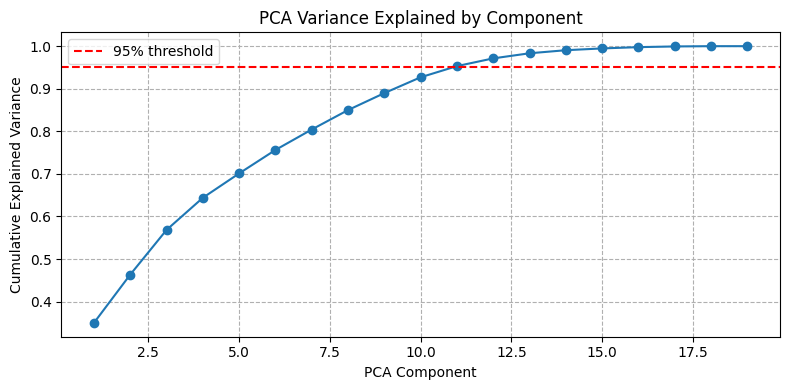

? Top contributing features to PC1:


,PC1,PC2,PC3
spectral_entropy,0.372701,0.048549,0.008005
fft_peak_3,0.369387,0.041819,0.007845
fft_peak_4,0.368845,0.037000,0.006960
fft_peak_2,0.367024,0.048941,0.008636
fft_peak_1,0.347445,0.060501,0.007934
rise_index,0.298395,0.091876,0.012701
rms_power,0.298039,0.035143,0.014508
phase_noise,0.245268,0.188452,0.037155
time_entropy,0.228749,0.246077,0.049117
cfo_estimate_hz,0.126567,0.152486,0.023466


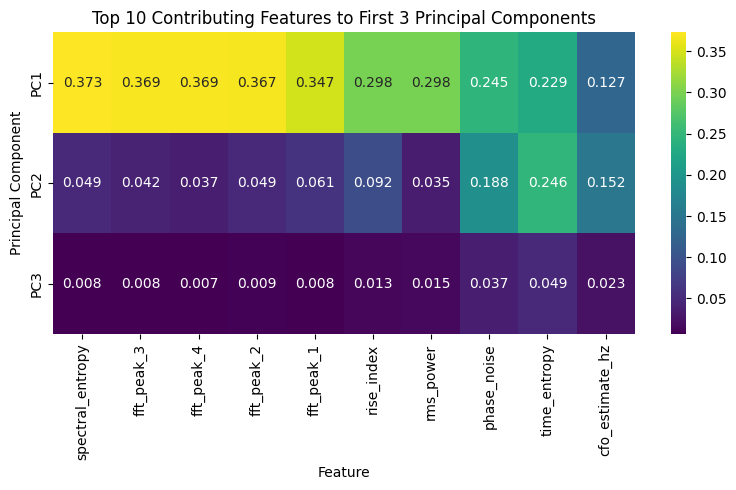

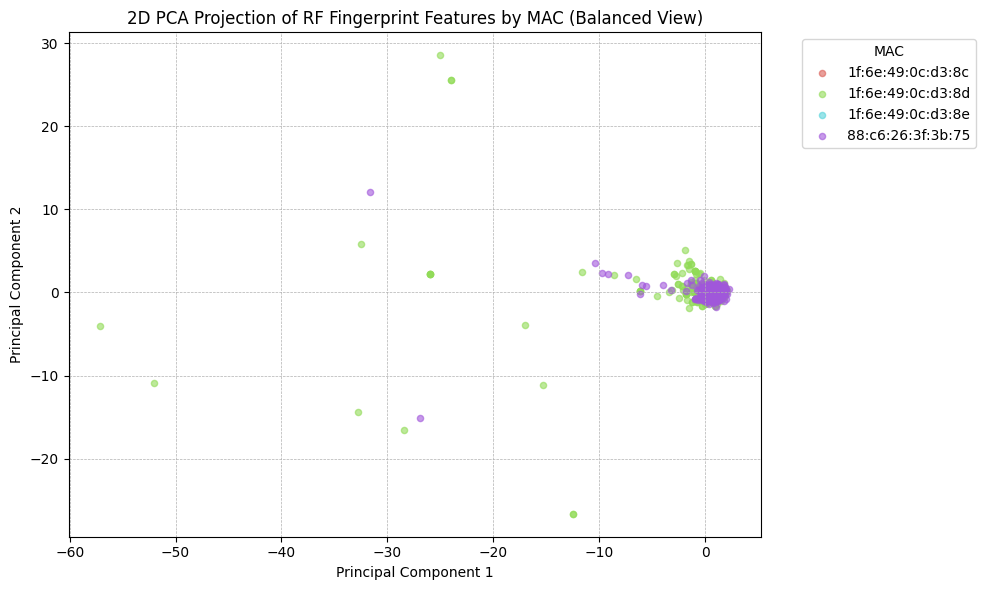

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Select numeric features
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_exploded.columns
    if col not in exclude_cols and not isinstance(df_exploded[col].iloc[0], (str, dict, list))
]

# --- Clean NaNs and match labels
X_raw = df_exploded[feature_cols]
mac_labels_raw = df_exploded['matched_macs'].fillna("Unknown").astype(str)
valid_idx = X_raw.dropna().index
X_clean = X_raw.loc[valid_idx]
mac_labels_clean = mac_labels_raw.loc[valid_idx]

print(f"? X_clean shape: {X_clean.shape}, mac_labels_clean shape: {mac_labels_clean.shape}")

# --- Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# --- Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Plot cumulative variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained by Component")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

# --- Top contributing features to first 3 PCs
loading_matrix = pd.DataFrame(
    pca_full.components_[:3],
    columns=X_clean.columns,
    index=["PC1", "PC2", "PC3"]
)
top_features = loading_matrix.abs().T.sort_values("PC1", ascending=False).head(10)
print("? Top contributing features to PC1:")
display(top_features)

# --- Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(top_features.T, annot=True, fmt=".3f", cmap="viridis", cbar=True)
plt.title("Top 10 Contributing Features to First 3 Principal Components")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

# --- 2D PCA visualization with optional balancing
from sklearn.utils import resample
df_vis = pd.DataFrame(X_scaled, columns=feature_cols, index=X_clean.index)
df_vis["mac"] = mac_labels_clean

# Take max 500 samples per MAC
df_samples = pd.concat([
    resample(g, n_samples=min(500, len(g)), random_state=42)
    for _, g in df_vis.groupby("mac")
])

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(df_samples[feature_cols])
mac_labels_vis = df_samples["mac"].values

# --- 2D scatter plot
plt.figure(figsize=(10, 6))
unique_macs = sorted(pd.Series(mac_labels_vis).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels_vis == mac)
    plt.scatter(X_vis[idx, 0], X_vis[idx, 1], s=20, alpha=0.6,
                label=mac, color=palette[i % len(palette)])

plt.title("2D PCA Projection of RF Fingerprint Features by MAC (Balanced View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(title="MAC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


X_clean shape: (124978, 19), MAC labels: (127026,)


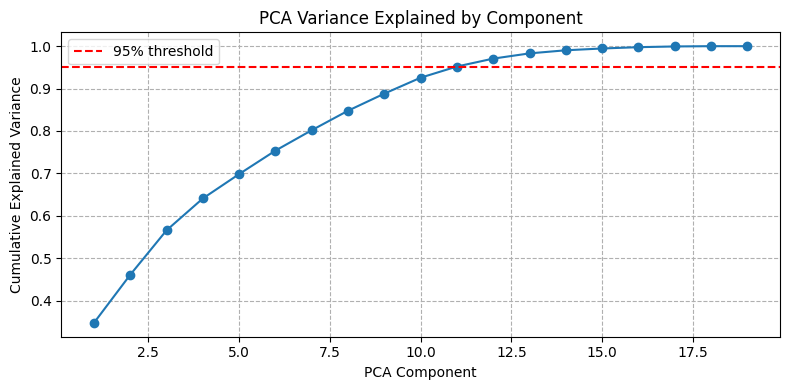

? Components needed for >=95% variance: 11
? Top contributing features to PC1:


,PC1,PC2,PC3
spectral_entropy,0.373581,0.048706,0.008770
fft_peak_3,0.370562,0.041787,0.009065
fft_peak_4,0.370023,0.037066,0.008021
fft_peak_2,0.368137,0.048809,0.009969
fft_peak_1,0.348539,0.060310,0.009132
rms_power,0.297142,0.031852,0.012483
rise_index,0.296634,0.101620,0.014883
phase_noise,0.246091,0.190381,0.040298
time_entropy,0.223648,0.249174,0.058751
fft_peak_0,0.127276,0.098575,0.014754


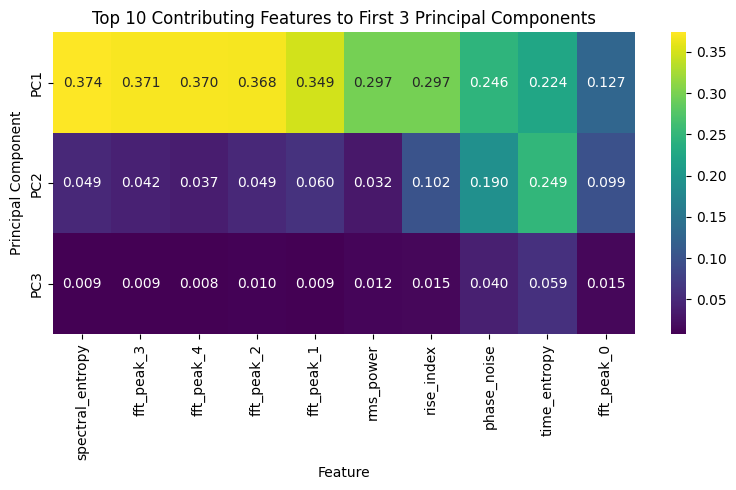

IndexError: boolean index did not match indexed array along axis 0; size of axis is 124978 but size of corresponding boolean axis is 127026

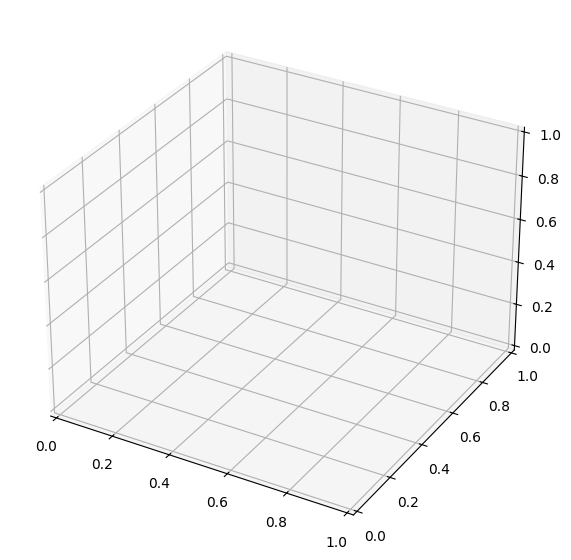

In [24]:
# --- Setup
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# --- Select numeric features
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_exploded.columns
    if col not in exclude_cols and not isinstance(df_exploded[col].iloc[0], (str, dict, list))
]

# --- Prepare and scale data
X = df_exploded[feature_cols]
mac_labels_all = df_exploded['matched_macs'].fillna("Unknown").astype(str)

# Drop rows with NaN (for both X and MAC labels)
X_clean = X.dropna()
mac_labels_clean = mac_labels_all.loc[X_clean.index].values  # <-- MATCH the cleaned index

print(f"X_clean shape: {X_clean.shape}, MAC labels: {mac_labels_clean.shape}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# --- Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained by Component")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

# --- Identify how many PCs needed
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"? Components needed for >=95% variance: {n_components}")

# --- Top contributing features
loading_matrix = pd.DataFrame(
    pca_full.components_[:3], columns=feature_cols, index=["PC1", "PC2", "PC3"]
)
top_features = loading_matrix.abs().T.sort_values("PC1", ascending=False).head(10)

print("? Top contributing features to PC1:")
display(top_features)

# --- Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(top_features.T, annot=True, fmt=".3f", cmap="viridis", cbar=True)
plt.title("Top 10 Contributing Features to First 3 Principal Components")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

# --- 3D PCA projection
pca_vis = PCA(n_components=3)
X_vis = pca_vis.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
unique_macs = sorted(pd.Series(mac_labels_clean).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels_clean == mac)
    ax.scatter(X_vis[idx, 0], X_vis[idx, 1], X_vis[idx, 2],
               label=mac, alpha=0.6, s=20, color=palette[i % len(palette)])

ax.set_title("3D PCA Projection of RF Fingerprint Features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.view_init(elev=30, azim=135)
ax.legend(title="MAC", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()
